In [11]:
from langchain_ollama import ChatOllama
from dotenv import load_dotenv 
load_dotenv() 
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

In [2]:
import os 
llm = ChatOllama(
    model="gpt-oss:20b-cloud",
    base_url = os.getenv("OLLAMA_BASE_URL"),
    headers = {"Authorization":f"Bearer {os.getenv("OLLAMA_API_KEY")}"}
)

In [3]:
class QuadState(TypedDict):
    a:int 
    b:int 
    c:int 
    equation: str 
    discriminant: str 
    result: str 

In [4]:
def show_eq(state:QuadState)->QuadState:
    equation = f'{state['a']}X^2+{state['b']}X+{state['c']}'
    state['equation']=equation 
    return state 

In [5]:
def calc_disc(state:QuadState)->QuadState:
    disc = (state['b']**2 - (4*state['a']*state['c']))/2*state['a']
    state['discriminant']=disc 
    return state 

In [7]:
def real_roots(state:QuadState)->QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    d = b**2 - 4*a*c 
    root1 = (-b + d**0.5) / (2*a)
    root2 = (-b - d**0.5) / (2*a)
    result = f'The First root is {root1} and Second root is {root2}' 
    return {'result':result} 

In [8]:
def equal_roots(state:QuadState)->QuadState:
    root = (-state['b'])/(2*state['a']) 
    result = f"The Only root is {root}" 
    return {'result':result} 

In [9]:
def no_roots(state:QuadState)->QuadState:
    result='No real roots'
    return {'result':result} 

In [21]:
def check_condition(state:QuadState)->Literal["real_roots","equal_roots","no_roots"]:
    disc = state['discriminant'] 
    if disc>0:
        return real_roots 
    elif disc==0:
        return equal_roots 
    else:
        return no_roots 
    

In [22]:
graph=StateGraph(QuadState) 
graph.add_node('show_eq',show_eq)
graph.add_node('calc_disc',calc_disc)
graph.add_node('real_roots',real_roots) 
graph.add_node('equal_roots',equal_roots) 
graph.add_node('no_roots',no_roots) 
graph.add_edge(START,'show_eq')
graph.add_edge('show_eq','calc_disc') 
graph.add_conditional_edges('calc_disc',check_condition)
graph.add_edge('real_roots',END)
graph.add_edge('equal_roots',END)
graph.add_edge('no_roots',END)
workflow=graph.compile()


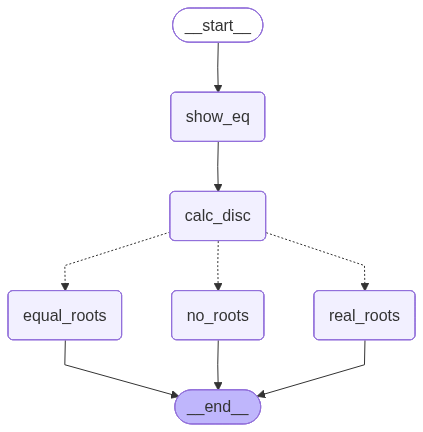

In [23]:
from IPython.display import Image 
Image(workflow.get_graph().draw_mermaid_png())